In [11]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [12]:
import pandas as pd
df = pd.read_csv("..\data\metadata_(for_scores).csv")
df.head()

,img_id,patient_id,lesion_id,gender,skin_cancer_diagnosis,diagnostic,biopsed,mask_components,melanoma_color_count,melanoma_colors,hue_variance,saturation_variance,value_variance,Polsby-Popper,mabrouk_asymmetry_score,avg_asymmetry_score
0,PAT_684_1303_368.png,PAT_684,1303,MALE,1,BCC,True,2,1,blue_gray,0.003734,0.014368,0.013598,12.927124,0,0.255860
1,PAT_842_1606_971.png,PAT_842,1606,FEMALE,1,BCC,True,3,1,blue_gray,0.143109,0.001537,0.003105,13.378031,0,0.118523
2,PAT_113_172_610.png,PAT_113,172,MALE,1,SCC,True,2,2,"red, blue_gray",0.002274,0.018044,0.004772,12.690194,0,0.096642
3,PAT_1633_2855_460.png,PAT_1633,2855,NaN,0,ACK,False,5,0,NaN,0.001311,0.001702,0.002817,17.035902,0,0.228686
4,PAT_168_262_74.png,PAT_168,262,MALE,1,BCC,True,1,1,blue_gray,0.008007,0.015162,0.003787,10.120009,0,0.280652


In [15]:
from sklearn.model_selection import train_test_split

x = df[['melanoma_color_count','hue_variance', 'saturation_variance', 'value_variance', 'Polsby-Popper', 'mabrouk_asymmetry_score', 'avg_asymmetry_score']]
y = df[['skin_cancer_diagnosis']]

dev_x, test_x, dev_y, test_y = train_test_split(
        x, y, stratify=y, random_state=0)

train_x, val_x, train_y, val_y = train_test_split(
        dev_x, dev_y, stratify=dev_y, random_state=0)

In [16]:
x

,melanoma_color_count,hue_variance,saturation_variance,value_variance,Polsby-Popper,mabrouk_asymmetry_score,avg_asymmetry_score
0,1,0.003734,0.014368,0.013598,12.927124,0,0.255860
1,1,0.143109,0.001537,0.003105,13.378031,0,0.118523
2,2,0.002274,0.018044,0.004772,12.690194,0,0.096642
3,0,0.001311,0.001702,0.002817,17.035902,0,0.228686
4,1,0.008007,0.015162,0.003787,10.120009,0,0.280652
...,...,...,...,...,...,...,...
2089,0,0.007189,0.000370,0.006851,9.142351,0,0.072210
2090,0,0.001615,0.002899,0.002817,8.158146,0,0.148728
2091,0,0.001357,0.004829,0.002076,9.226173,0,0.122775
2092,0,0.017869,0.006313,0.000669,10.092346,1,0.236075


In [17]:
decision_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=1907,
    
    )
decision_tree.fit(train_x, train_y)

print(f"Mean accuracy: {decision_tree.score(val_x, val_y)}")
print(f"Train accuracy: {decision_tree.score(train_x, train_y)}")

Mean accuracy: 0.5572519083969466
Train accuracy: 1.0


In [21]:
#fig, ax = plt.subplots(2, 3, figsize=(10, 6))
depths = range(1, 9)

for i, d in enumerate(depths):
    decision_tree = DecisionTreeClassifier(max_depth=d, random_state=1907)
    decision_tree.fit(train_x,train_y)

    # plot
    #row, col = i // 3, i % 3
    #DecisionBoundaryDisplay.from_estimator(decision_tree,train_x,alpha=0.5, ax=ax[row, col])
    #ax[row, col].scatter(val_x[:,0],val_x[:,1],c=val_y)
    #ax[row, col].set_title(f"max_depth={d}")
    print(f"max_depth= {d} - Train accuracy: {decision_tree.score(train_x,train_y)} - Val accuracy: {decision_tree.score(val_x,val_y)}")

max_depth= 1 - Train accuracy: 0.6176720475785896 - Val accuracy: 0.6310432569974554
max_depth= 2 - Train accuracy: 0.6176720475785896 - Val accuracy: 0.6310432569974554
max_depth= 3 - Train accuracy: 0.6406117247238743 - Val accuracy: 0.6157760814249363
max_depth= 4 - Train accuracy: 0.6499575191163977 - Val accuracy: 0.6081424936386769
max_depth= 5 - Train accuracy: 0.6864910790144435 - Val accuracy: 0.6157760814249363
max_depth= 6 - Train accuracy: 0.7119796091758709 - Val accuracy: 0.6132315521628499
max_depth= 7 - Train accuracy: 0.7434154630416313 - Val accuracy: 0.6157760814249363
max_depth= 8 - Train accuracy: 0.7774001699235344 - Val accuracy: 0.5623409669211196


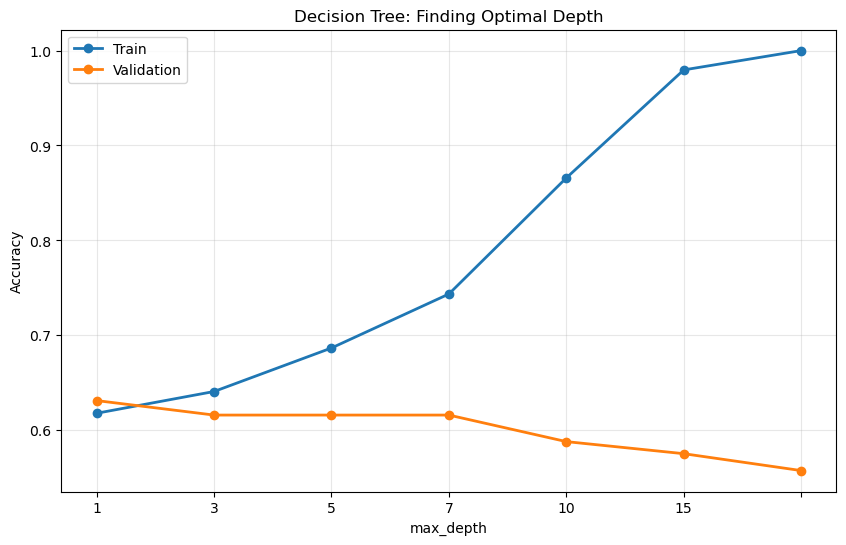

In [19]:
depths = [1, 3, 5, 7, 10, 15, None]
train_accs = []
val_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=1907)
    dt.fit(train_x, train_y)
    train_accs.append(dt.score(train_x, train_y))
    val_accs.append(dt.score(val_x, val_y))

plt.figure(figsize=(10, 6))
plt.plot(range(len(depths)), train_accs, marker='o', label='Train', linewidth=2)
plt.plot(range(len(depths)), val_accs, marker='o', label='Validation', linewidth=2)
plt.xticks(range(len(depths)), depths)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Decision Tree: Finding Optimal Depth')
plt.grid(True, alpha=0.3)
plt.show()

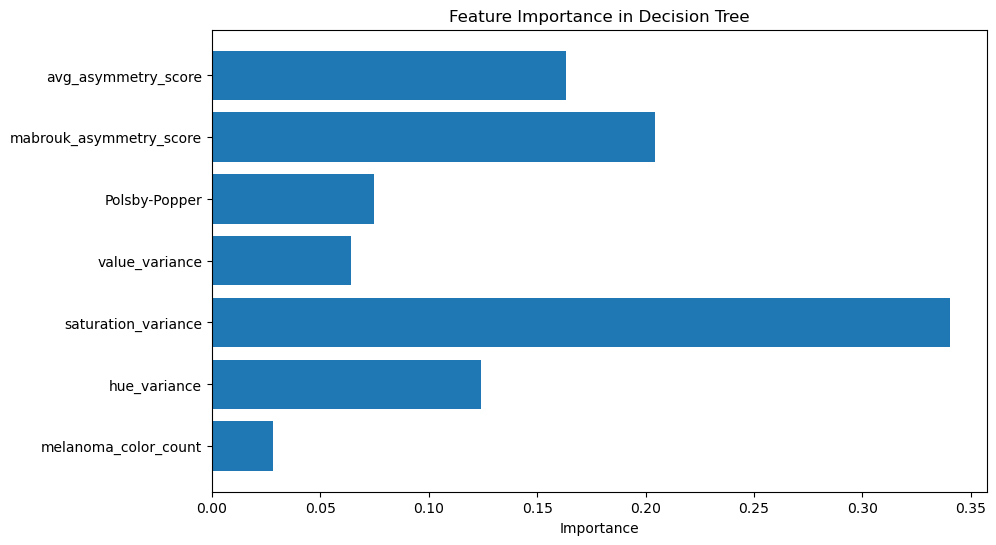

In [20]:
# Train your best model
dt = DecisionTreeClassifier(max_depth=5, random_state=1907)
dt.fit(train_x, train_y)

# See which features are most important
feature_names = ['melanoma_color_count','hue_variance', 'saturation_variance', 
                 'value_variance', 'Polsby-Popper', 'mabrouk_asymmetry_score', 'avg_asymmetry_score']

plt.figure(figsize=(10, 6))
plt.barh(feature_names, dt.feature_importances_)
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.show()